In [99]:
import os

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import geopandas as gpd
import numpy as np

In [100]:
gdf = gpd.read_file("../../geodata/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")[['ADM0_A3', 'geometry']].to_crs('+proj=robin')
gdf.sample(5)

,ADM0_A3,geometry
224,GGY,"MULTIPOLYGON (((-212315.035 5274456.160, -2106..."
56,KHM,"MULTIPOLYGON (((10060615.963 1572682.727, 1006..."
51,LVA,"POLYGON ((2111191.184 6091885.462, 2124699.738..."
9,CHN,"MULTIPOLYGON (((7073409.139 3570802.392, 70732..."
20,SOL,"POLYGON ((4597212.526 1203116.053, 4597702.054..."


In [101]:
df = pd.read_csv("../../V_Dem_Index/V-Dem-CY-FullOthers_csv_v13/V-Dem-CY-Core-v13.csv")
df.sample(5)

,country_name,country_text_id,country_id,year,historical_date,project,historical,histname,codingstart,codingend,...,v2xme_altinf_sd,v2xps_party,v2xps_party_codelow,v2xps_party_codehigh,v2x_divparctrl,v2x_feduni,v2xca_academ,v2xca_academ_codelow,v2xca_academ_codehigh,v2xca_academ_sd
24394,Romania,ROU,190,1909,1909-12-31,2,1,Kingdom of Romania,1789,2022,...,0.645,0.537,0.392,0.666,1.321,0.473,0.513,0.410,0.610,0.603
2700,Brazil,BRA,19,1813,1813-12-31,1,1,Viceroyalty of Brazil,1789,2022,...,0.666,NaN,NaN,NaN,NaN,0.333,NaN,NaN,NaN,NaN
358,Sweden,SWE,5,1790,1790-12-31,1,1,Kingdom of Sweden,1789,2022,...,0.667,0.070,0.007,0.205,NaN,0.109,NaN,NaN,NaN,NaN
22587,Kuwait,KWT,171,2017,2017-12-31,0,1,State of Kuwait,1789,2022,...,0.642,0.108,0.046,0.175,0.816,0.000,0.501,0.403,0.606,0.603
5268,Afghanistan,AFG,36,1795,1795-12-31,1,1,Emirate of Afghanistan,1789,2022,...,0.667,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN


In [102]:
year_2022 = df.loc[df['year'] == 2022]
year_2022.sample(5)

,country_name,country_text_id,country_id,year,historical_date,project,historical,histname,codingstart,codingend,...,v2xme_altinf_sd,v2xps_party,v2xps_party_codelow,v2xps_party_codehigh,v2x_divparctrl,v2x_feduni,v2xca_academ,v2xca_academ_codelow,v2xca_academ_codehigh,v2xca_academ_sd
11337,Ecuador,ECU,75,2022,2022-12-31,0,1,Republic of Ecuador,1830,2022,...,0.642,0.350,0.270,0.440,1.342,0.957,0.829,0.750,0.893,0.612
18526,Rwanda,RWA,129,2022,2022-12-31,0,0,Republic of Rwanda [independent state],1916,2022,...,0.653,0.557,0.412,0.699,-0.821,0.434,0.089,0.047,0.148,0.624
1293,Japan,JPN,9,2022,2022-12-31,0,1,State of Japan,1789,2022,...,0.649,0.831,0.676,0.916,-0.097,0.992,0.582,0.458,0.690,0.620
16045,Belarus,BLR,107,2022,2022-12-31,0,0,Republic of Belarus [independent state],1990,2022,...,0.649,0.547,0.403,0.692,-1.295,0.092,0.030,0.015,0.059,0.625
2675,Poland,POL,17,2022,2022-12-31,0,1,Republic of Poland,1789,2022,...,0.644,0.895,0.784,0.940,0.650,0.913,0.738,0.642,0.810,0.602


In [103]:
used_coloumns = year_2022.loc[:,["country_name","country_text_id","v2x_polyarchy","v2x_libdem","v2x_partipdem","v2x_delibdem","v2x_egaldem",]]
used_coloumns.sample(5)

,country_name,country_text_id,v2x_polyarchy,v2x_libdem,v2x_partipdem,v2x_delibdem,v2x_egaldem
13240,Malawi,MWI,0.642,0.538,0.406,0.511,0.382
7929,Benin,BEN,0.450,0.305,0.266,0.297,0.350
22647,Lithuania,LTU,0.797,0.741,0.588,0.648,0.687
5009,Sudan,SDN,0.169,0.074,0.090,0.063,0.102
20502,Croatia,HRV,0.738,0.648,0.507,0.587,0.577


In [104]:
merged = gdf.merge(used_coloumns, left_on='ADM0_A3', right_on='country_text_id')
merged["mean"] = merged.loc[:,["v2x_polyarchy","v2x_libdem","v2x_partipdem","v2x_delibdem","v2x_egaldem"]].mean(axis=1)
merged.sample(5)

,ADM0_A3,geometry,country_name,country_text_id,v2x_polyarchy,v2x_libdem,v2x_partipdem,v2x_delibdem,v2x_egaldem,mean
82,ITA,"MULTIPOLYGON (((591248.018 4902251.079, 595151...",Italy,ITA,0.844,0.766,0.668,0.768,0.775,0.7642
159,SYC,"MULTIPOLYGON (((4374891.592 -1039571.143, 4374...",Seychelles,SYC,0.761,0.675,0.325,0.688,0.634,0.6166
130,LSO,"POLYGON ((2637317.825 -3091857.976, 2638649.63...",Lesotho,LSO,0.641,0.504,0.401,0.493,0.505,0.5088
90,NGA,"MULTIPOLYGON (((337689.306 1250885.400, 342502...",Nigeria,NGA,0.490,0.320,0.327,0.322,0.266,0.3450
85,NLD,"MULTIPOLYGON (((575752.161 5660240.445, 576112...",Netherlands,NLD,0.852,0.800,0.580,0.804,0.765,0.7602


In [105]:
colors = 8
cmap = 'PiYG'
figsize = (16, 10)
year = '2022'
cols = ['Country Name', 'Country Code', year]
norm = mpl.colors.Normalize(vmin=0, vmax=1)

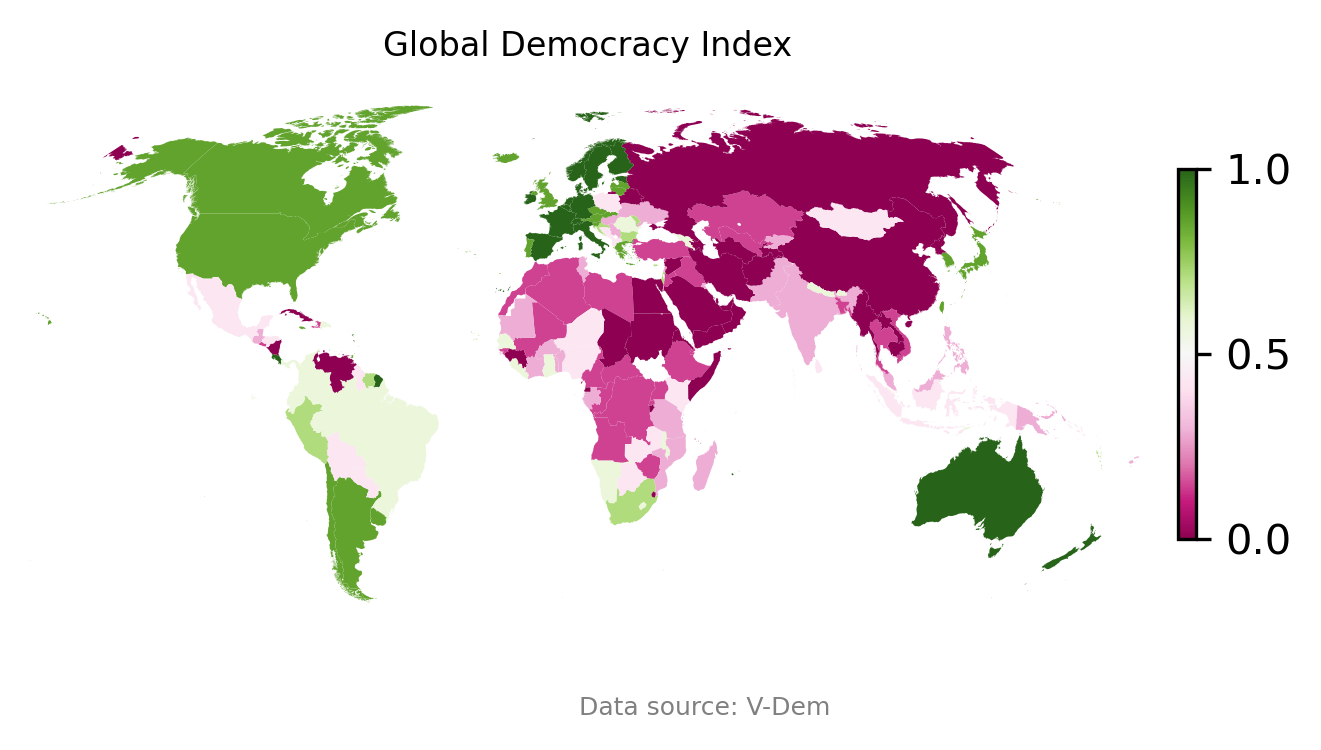

In [106]:
fig,ax = plt.subplots(figsize=(6,4),dpi = 300)


merged.plot(column="mean", cmap=cmap, figsize=figsize, scheme='equal_interval', k=colors, legend=False,ax=ax)

ax.set_axis_off()
ax.set_xlim([-1.5e7, 1.7e7])
ax.set_title("Global Democracy Index",fontdict={'fontsize': 8}, )

colorbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), orientation='vertical',ax=ax,shrink=0.4,anchor=(-0.2, 0.5) )
labels = colorbar.ax.set_yticks([0,0.5,1])
fig.text(0.5, 0.2, 'Data source: V-Dem', ha='center', va='center', fontsize=6, color='gray')


plt.savefig("../../grafiken/worldmap.png",bbox_inches = "tight",dpi = 300)

# Second Plot

In [107]:
import pycountry_convert as pc
from pycountry_convert import convert_country_alpha2_to_continent_code as convert_code

In [108]:
df_progression = df.copy(deep=True)

In [109]:

for index,element in enumerate(df_progression["country_text_id"]):
    try:
        if pc.country_alpha3_to_country_alpha2(element):
            df_progression.loc[index,("continent")] = pc.convert_continent_code_to_continent_name(convert_code.country_alpha2_to_continent_code(pc.country_alpha3_to_country_alpha2(element)))
    except:
        continue


In [110]:
df_progression["country_name"].dropna()

0                   Mexico
1                   Mexico
2                   Mexico
3                   Mexico
4                   Mexico
               ...        
27550    Piedmont-Sardinia
27551    Piedmont-Sardinia
27552    Piedmont-Sardinia
27553    Piedmont-Sardinia
27554    Piedmont-Sardinia
Name: country_name, Length: 27555, dtype: object

In [111]:
df_progression = df_progression.loc[:,["country_name","country_text_id","v2x_polyarchy","v2x_libdem","v2x_partipdem","v2x_delibdem","v2x_egaldem","year","continent"]]

In [112]:
df_progression["mean"] = df_progression.loc[:,["v2x_polyarchy","v2x_libdem","v2x_partipdem","v2x_delibdem","v2x_egaldem"]].mean(axis=1)
df_progression.sample(4)

,country_name,country_text_id,v2x_polyarchy,v2x_libdem,v2x_partipdem,v2x_delibdem,v2x_egaldem,year,continent,mean
20831,Cyprus,CYP,0.774,0.634,0.497,0.650,0.622,1994,Asia,0.6354
14285,Qatar,QAT,0.020,0.093,0.017,0.058,0.110,2000,Asia,0.0596
5678,Argentina,ARG,0.113,0.085,0.155,0.125,0.138,1971,South America,0.1232
27336,Oldenburg,OLD,NaN,NaN,NaN,NaN,NaN,1842,NaN,NaN


In [113]:
df_progression.dropna(inplace=True,axis=0,subset=["continent"])

In [114]:
continents = ["North America", "South America" , "Europe", "Africa" ,"Asia" , "Oceania","mean"]

In [115]:
continent_progression_list = []
for continent in continents:
    for year in range(1800,2023):
        av = df_progression.loc[(df_progression["continent"] == continent) & (df_progression["year"] == year)]["mean"].mean()
        continent_progression_list.append((year,continent,av))


In [116]:
df_continent_progression = pd.DataFrame(continent_progression_list,columns=["year","continent","mean"])
df_continent_progression = df_continent_progression[df_continent_progression["year"] >= 1900]

In [117]:
for year in range(1900,2023):
    df_continent_progression.loc[(df_continent_progression["continent"] == "mean") & (df_continent_progression["year"] == year ),"mean"] = df_continent_progression.loc[df_continent_progression["year"] == year]["mean"].mean()

In [193]:
style= {"North America": {"color" : "gray" ,"linewidth" : 2,},
       "South America": {"color" : "gray", "linewidth" :2,},
       "Europe": {"color" : "gray", "linewidth" :2},
       "Africa": {"color" : "gray", "linewidth" :2,},
       "Asia": {"color" : "gray", "linewidth" :2,},
       "Oceania": {"color" : "gray", "linewidth" :2,},
       "mean": {"color" : "darkblue",  "alpha" : 1, "linewidth" :2,"zorder":-1}}

style_fill={"alpha": 0.5,"zorder":-2}

In [194]:
def get_ax_continent(continent,axs):
    if continent == "North America":
        return axs[0,0]
    elif continent == "South America":
        return axs[1,0]
    elif continent == "Europe":
        return axs[0,2]
    elif continent == "Africa":
        return axs[1,2]
    elif continent == "Asia":
        return axs[0,3]
    elif continent == "Oceania":
        return axs[1,4]

In [195]:
def remove_all_spines(ax):
    ax.spines[['right', 'top',"left","bottom"]].set_visible(False)

In [196]:
cmap = plt.get_cmap('PiYG')
cmap(0)

(0.5568627450980392, 0.00392156862745098, 0.3215686274509804, 1.0)

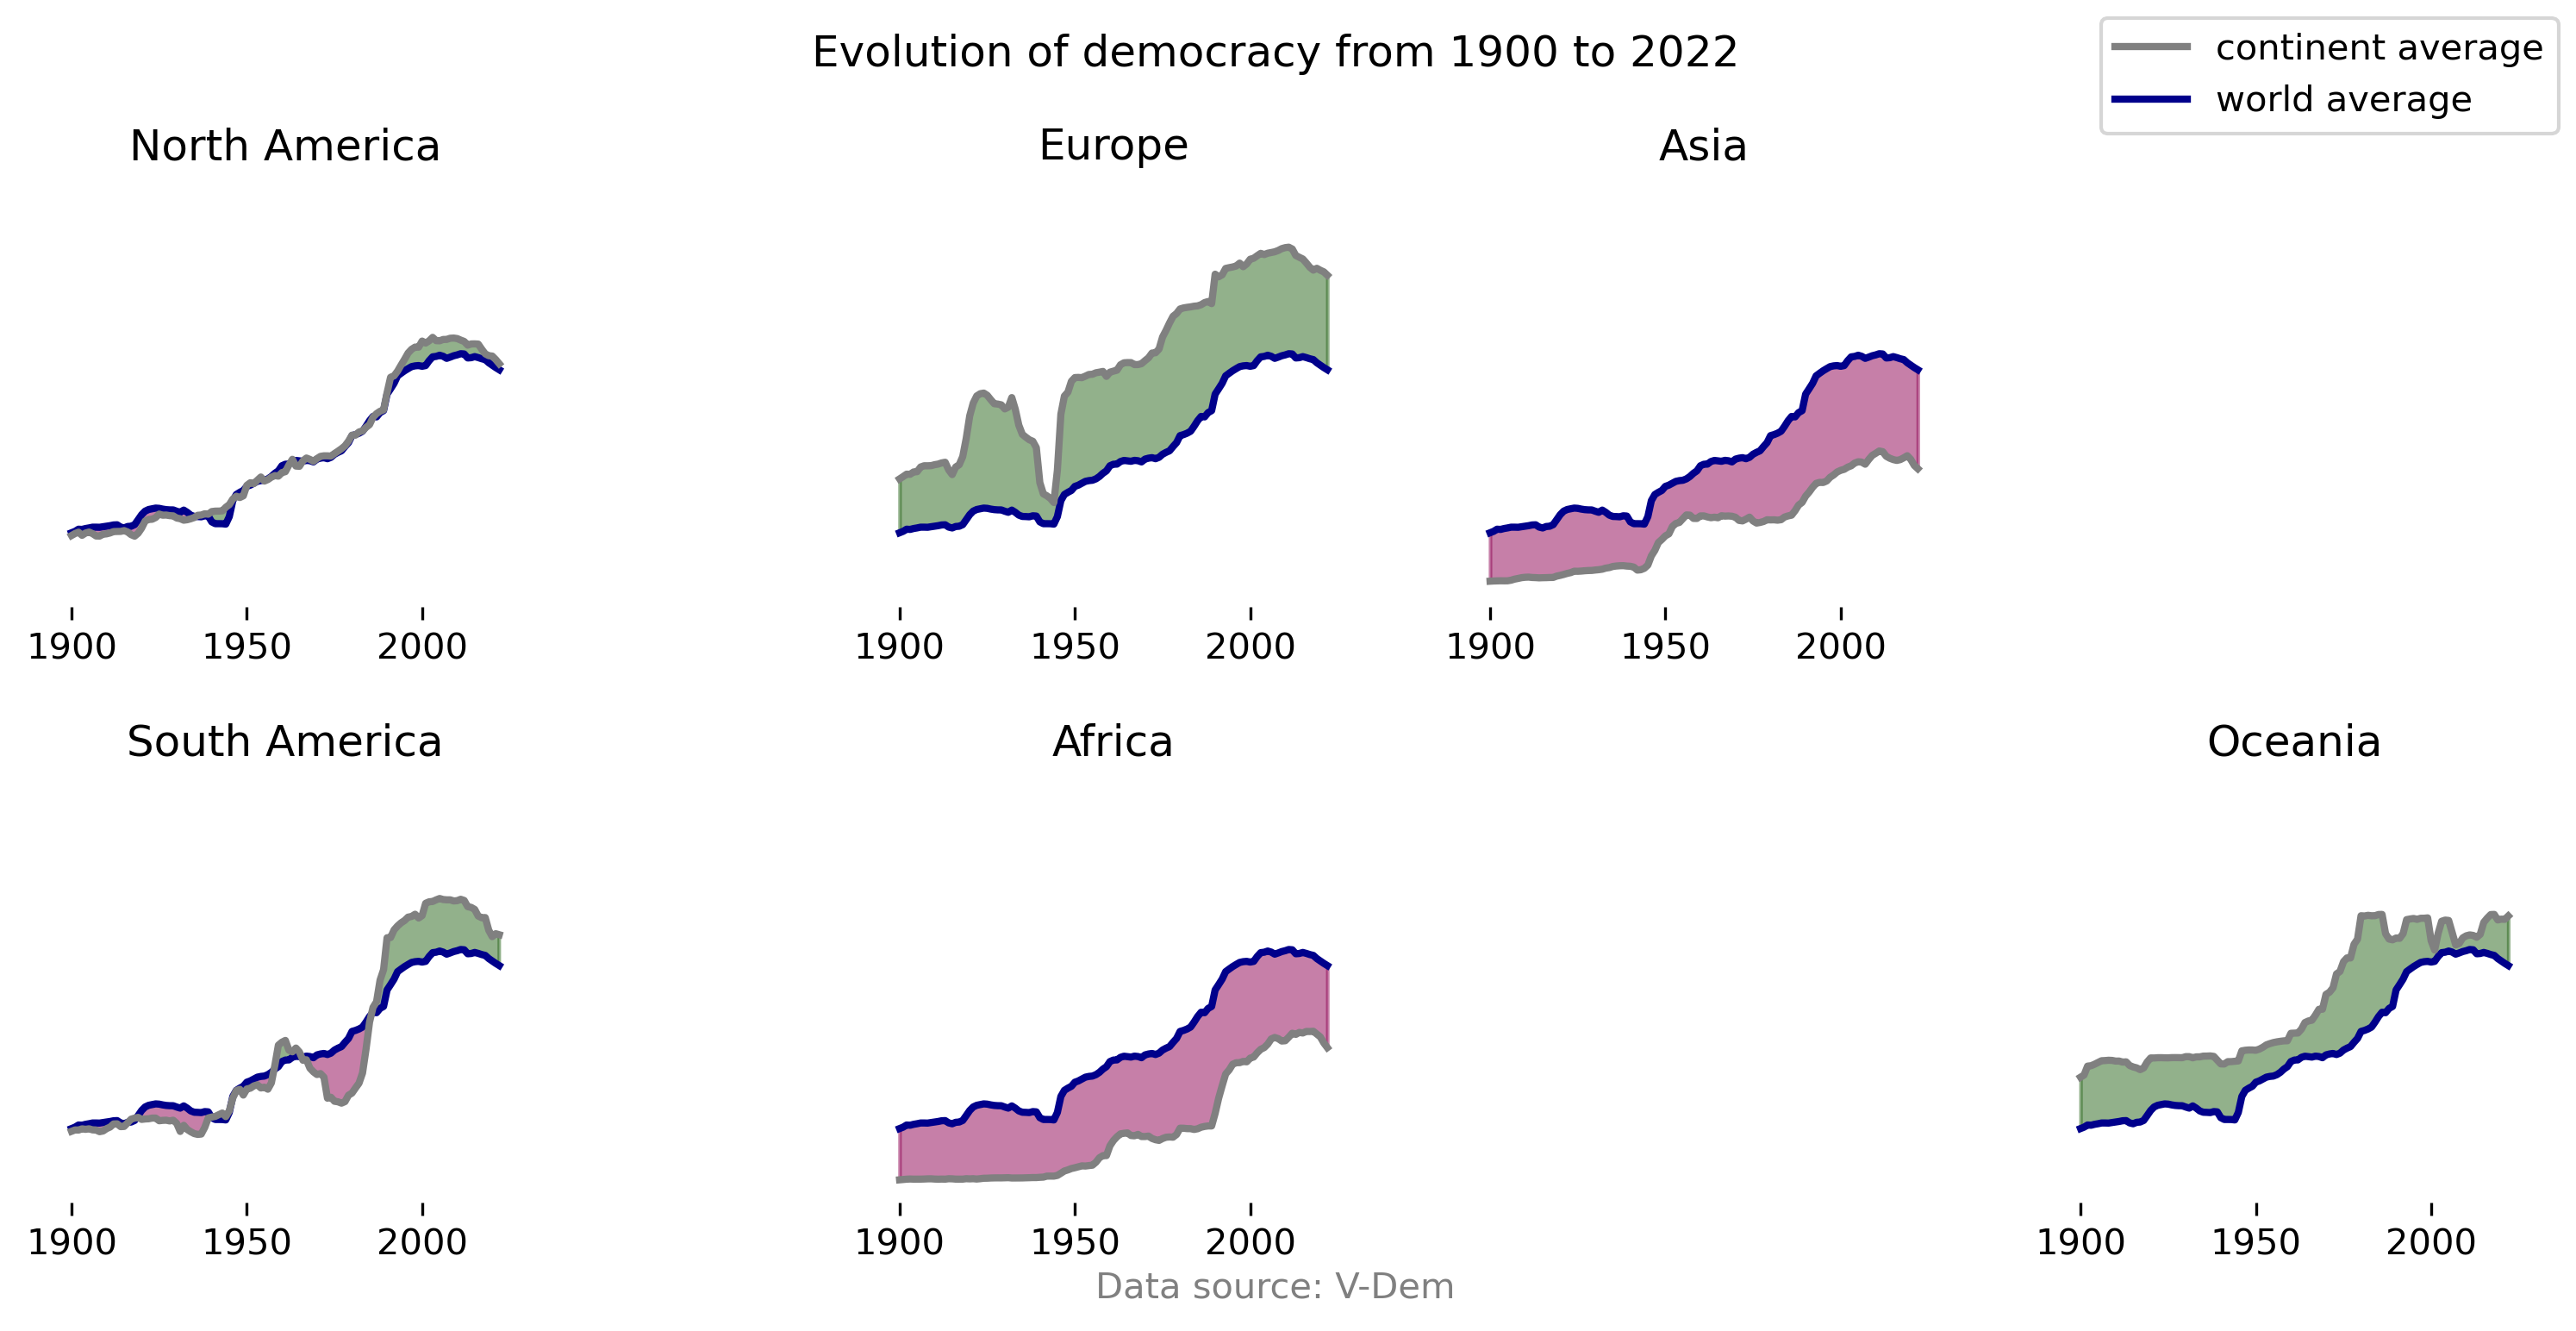

In [197]:
fig,axs = plt.subplots(figsize=(10,5),dpi = 300,nrows = 2, ncols = 5,width_ratios=[4,1,4,4,4])
plt.subplots_adjust(hspace=0.3,wspace=0.3,)

colors = [cmap(0),cmap(400)]


continents_plot = ["North America", "South America" , "Europe", "Africa" ,"Asia" , "Oceania"]

for continent in continents_plot:
    ax = get_ax_continent(continent,axs)

    y_continent = df_continent_progression.loc[df_continent_progression["continent"] == continent]["mean"]
    y_mean = df_continent_progression.loc[df_continent_progression["continent"] == "mean"]["mean"]
    x_year = df_continent_progression.loc[df_continent_progression["continent"] == continent]["year"]

    ax.plot(x_year,y_continent,**style[continent])
    ax.plot(x_year,y_mean,**style["mean"])

    ax.fill_between(x_year,y_continent,y_mean, where=(y_continent.values < y_mean.values),color = colors[0],**style_fill)
    ax.fill_between(x_year,y_continent,y_mean, where=(y_continent.values > y_mean.values),color = colors[1], **style_fill)

    #ax.scatter(y=df_continent_progression[(df_continent_progression["continent"] == continent) & (df_continent_progression["year"] == 2022)]["mean"],x=2022,marker="o",**style[continent])

    remove_all_spines(ax)
    ax.tick_params(left=False,labelleft=False,bottom = True,labelbottom = True)

    ax.set_yticks([0,0.2,0.4,0.6,0.8])
    ax.set_title(continent)

axs_no_graph = [axs[0,1],axs[1,1],axs[0,4],axs[1,3]]

for ax in axs_no_graph:
    ax.tick_params(left=False,labelleft=False,bottom = False,labelbottom = False)
    remove_all_spines(ax)


fig.legend(['continent average', 'world average'])
title = fig.suptitle("Evolution of democracy from 1900 to 2022")
fig.text(0.5, 0.01, 'Data source: V-Dem', ha='center', va='center', fontsize=10, color='gray')


fig.tight_layout()
plt.subplots_adjust(hspace=0.4,wspace=0.3)
plt.savefig("../../grafiken/progression.png",bbox_inches = "tight",dpi = 200)

## 3rd Plot weighted with population


In [123]:
df_weighted = df_progression.copy(deep=True)
df_weighted = df_weighted[df_weighted["year"] >= 1970]

In [124]:
population_df = pd.read_csv("../../world_population/World Population Live Dataset.csv")
population_df

,CCA3,Name,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),GrowthRate,World Population Percentage,Rank
0,CN,China,1425887,1424930,1393715,1348191,1264099,1153704,982372,822534,9706961,146.8933,1.00,17.88%,1
1,IN,India,1417173,1396387,1322867,1240614,1059634,870452,696828,557501,3287590,431.0675,1.01,17.77%,2
2,US,United States,338290,335942,324608,311183,282399,248084,223140,200328,9372610,36.0935,1.00,4.24%,3
3,ID,Indonesia,275501,271858,259092,244016,214072,182160,148177,115228,1904569,144.6529,1.01,3.45%,4
4,PK,Pakistan,235825,227197,210969,194454,154370,115414,80624,59291,881912,267.4018,1.02,2.96%,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,MS,Montserrat,4,5,5,5,5,11,11,11,102,43.0392,0.99,0.00%,230
230,FK,Falkland Islands,4,4,3,3,3,2,2,2,12173,0.3105,1.00,0.00%,231
231,NU,Niue,2,2,2,2,2,3,4,5,260,7.4385,1.00,0.00%,232
232,TK,Tokelau,2,2,1,1,2,2,2,2,12,155.9167,1.01,0.00%,233


In [125]:
def country_population(CCA3,year):


    intervals = [(1970,1980), (1980,1990),(2000,2010),(2015,2020),(2020,2022)]
    country_temp_df = population_df[population_df["CCA3"] == CCA3]
    for interval in intervals:
        if interval[0] <= year < interval[1]:
            population = (((country_temp_df[str(interval[1])] - country_temp_df[str(interval[0])]) / (interval[1] - interval[0])) * (year - interval[0]) +  country_temp_df[str(interval[0])])
            if len(population.values) != 0:
                return population.values[0]
        if year == 2022:
            population = country_temp_df["2022"]
            if len(population.values) != 0:
                return population.values[0]
    return pd.NA




In [126]:
list_population = []
for _,row in df_weighted.iterrows():
    list_population.append(country_population(pc.country_alpha3_to_country_alpha2(row["country_text_id"]),row["year"]))


In [127]:
df_weighted = df_weighted.assign(population = list_population)
df_weighted

,country_name,country_text_id,v2x_polyarchy,v2x_libdem,v2x_partipdem,v2x_delibdem,v2x_egaldem,year,continent,mean,population
181,Mexico,MEX,0.250,0.112,0.142,0.129,0.128,1970,North America,0.1522,50289.0
182,Mexico,MEX,0.247,0.112,0.146,0.127,0.127,1971,North America,0.1518,52030.6
183,Mexico,MEX,0.249,0.112,0.147,0.128,0.130,1972,North America,0.1532,53772.2
184,Mexico,MEX,0.250,0.112,0.147,0.128,0.131,1973,North America,0.1536,55513.8
185,Mexico,MEX,0.252,0.113,0.148,0.129,0.131,1974,North America,0.1546,57255.4
...,...,...,...,...,...,...,...,...,...,...,...
25984,Hungary,HUN,0.483,0.381,0.334,0.269,0.350,2018,Europe,0.3634,9788.2
25985,Hungary,HUN,0.466,0.368,0.323,0.271,0.335,2019,Europe,0.3526,9769.6
25986,Hungary,HUN,0.460,0.356,0.316,0.243,0.333,2020,Europe,0.3416,9751.0
25987,Hungary,HUN,0.455,0.350,0.305,0.222,0.328,2021,Europe,0.3320,9859.0


In [128]:
df_weighted.dropna(inplace=True,axis=0,subset=["population"])

In [129]:
df_weighted[df_weighted.columns[2:7]].mean()

v2x_polyarchy    0.421097
v2x_libdem       0.329438
v2x_partipdem    0.264603
v2x_delibdem     0.325608
v2x_egaldem      0.332291
dtype: float64

In [130]:
mean_list = []
for _,row in df_weighted.iterrows():
    mean_list.append(row[df_weighted.columns[2:7]].mean())


In [131]:
df_weighted = df_weighted.assign(mean = mean_list)

In [132]:
continents = ["North America", "South America" , "Europe", "Africa" ,"Asia" , "Oceania"]

In [133]:
THRESHOLD = 0.4

In [134]:
living_in_democracy_1970 = {}
for continent in continents:
    living_in_democracy_1970[continent] = df_weighted[(df_weighted["mean"] >= THRESHOLD)  & (df_weighted["year"] == 1970) & (df_weighted["continent"] == continent)]["population"].sum()

In [135]:
living_in_autocracy_1970 = {}
for continent in continents:
    living_in_autocracy_1970[continent] = df_weighted[(df_weighted["mean"] < THRESHOLD)  & (df_weighted["year"] == 1970) & (df_weighted["continent"] == continent)]["population"].sum()

In [136]:
living_in_democracy_2022 = {}
for continent in continents:
    living_in_democracy_2022[continent] = df_weighted[(df_weighted["mean"] >= THRESHOLD)  & (df_weighted["year"] == 2022) & (df_weighted["continent"] == continent)]["population"].sum()

In [137]:
living_in_autocracy_2022 = {}
for continent in continents:
    living_in_autocracy_2022[continent] = df_weighted[(df_weighted["mean"] < THRESHOLD)  & (df_weighted["year"] == 2022) & (df_weighted["continent"] == continent)]["population"].sum()

In [138]:
colors = [cmap(0),cmap(400)]

style_pie = {"colors": colors,"autopct" :'%1.1f%%',"pctdistance":1.25, "wedgeprops" : dict(width=0.5),}
style_text = {"fontsize" : 20}

### not used in data story

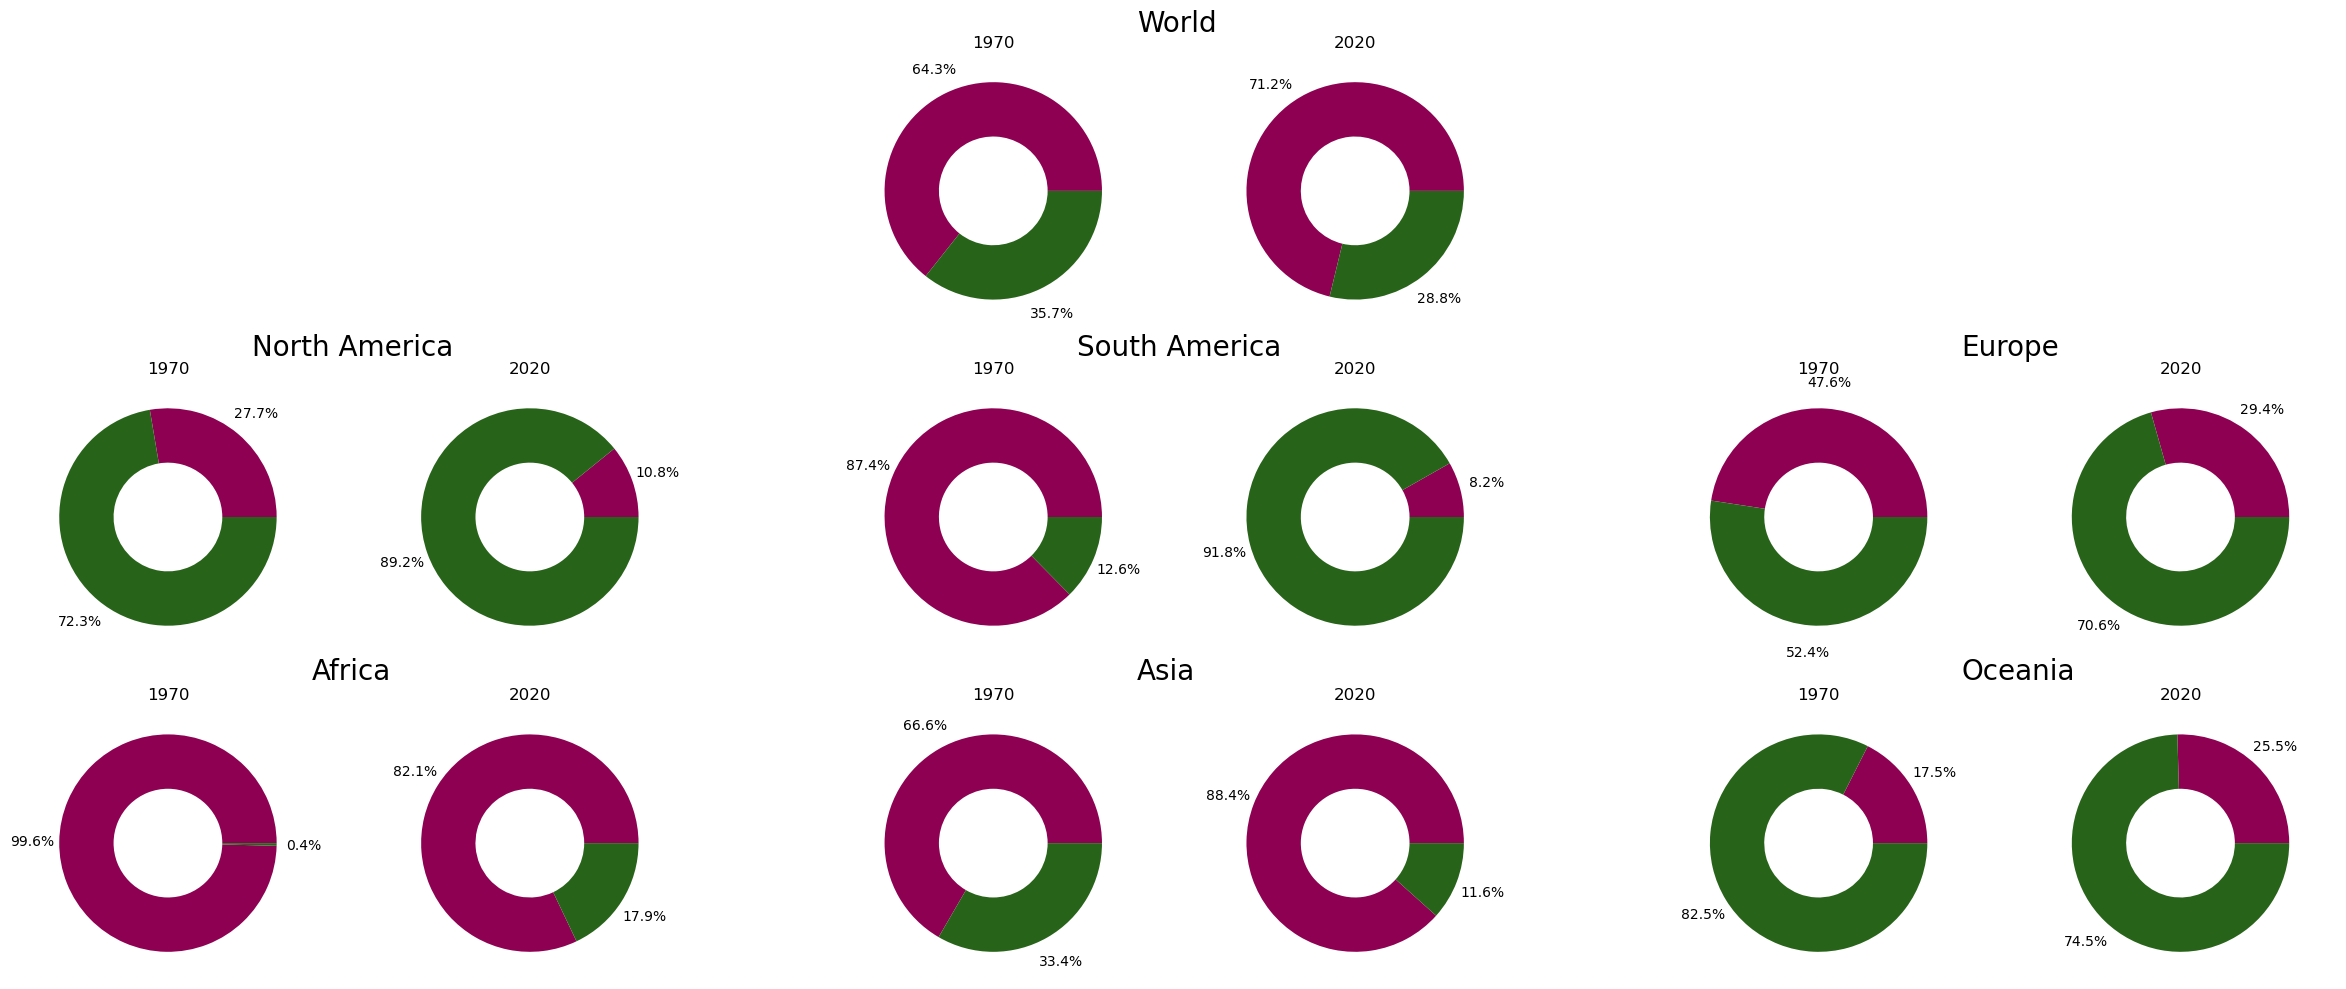

In [139]:
fig, axs = plt.subplots(figsize=(30,12), nrows=(3), ncols= 8,width_ratios = [6,6,1,6,6,1,6,6])


# World
sizes = [sum(living_in_autocracy_1970.values()),sum(living_in_democracy_1970.values())]
axs[0,3].pie(sizes,**style_pie)
axs[0,3].set_title("1970")

sizes = [sum(living_in_autocracy_2022.values()),sum(living_in_democracy_2022.values())]
axs[0,4].pie(sizes,**style_pie)
axs[0,4].set_title("2020")


iter_continents = iter(continents)

for index_y in range(1,3):
    for index_x in range(0,8,3):
        continent = next(iter_continents)
        sizes = [living_in_autocracy_1970[continent],living_in_democracy_1970[continent]]
        axs[index_y,index_x].pie(sizes,**style_pie)
        axs[index_y,index_x].set_title("1970")

        sizes = [living_in_autocracy_2022[continent],living_in_democracy_2022[continent]]
        axs[index_y,index_x + 1].pie(sizes,**style_pie)
        axs[index_y,index_x + 1].set_title("2020")


iter_continents = iter(continents)



#titles
fig.text(x = 0.5,y=0.9,s="World",**style_text)
fig.text(x = 0.205,y=0.63,s=next(iter_continents),**style_text)
fig.text(x = 0.48,y=0.63,s=next(iter_continents),**style_text)
fig.text(x = 0.775,y=0.63,s=next(iter_continents),**style_text)
fig.text(x = 0.225,y=0.36,s=next(iter_continents),**style_text)
fig.text(x = 0.5,y=0.36,s=next(iter_continents),**style_text)
fig.text(x = 0.775,y=0.36,s=next(iter_continents),**style_text)


axs[0,0].axis("off")
axs[0,1].axis("off")
axs[0,2].axis("off")
axs[0,5].axis("off")
axs[0,6].axis("off")
axs[0,7].axis("off")


axs[0,2].axis("off")
axs[0,5].axis("off")
axs[1,2].axis("off")
axs[1,5].axis("off")
axs[2,2].axis("off")
axs[2,5].axis("off")

plt.savefig("../../grafiken/people_autocracy_vs_democracy.png",bbox_inches = "tight",dpi = 200)

In [140]:
def sizes(autocracy,democray):
    sizes =  {"autocracy" : sum(autocracy.values()),"democracy" : sum(democray.values())}
    return sizes.items()

In [141]:
def normalize(data):
    data = np.array(data)
    for dimension in range(data.shape[0]):
        sum_data = (data[dimension][0] + data[dimension][1])
        data[dimension][0] = data[dimension][0] / sum_data
        data[dimension][1] = data[dimension][1] / sum_data
    return data
        

In [142]:
def format_label(label):
    for index in range(len(label)):
        if type(label[index]) != str:
            label[index] = str(round(label[index] * 100,1)) + "%"
    
    return label
    

In [143]:
continent = "Asia"
size = normalize([[living_in_autocracy_1970[continent],living_in_democracy_1970[continent]],
                [living_in_autocracy_2022[continent],living_in_democracy_2022[continent]]])

In [144]:
stacked_barplot_style = {"alpha" : 0.8}

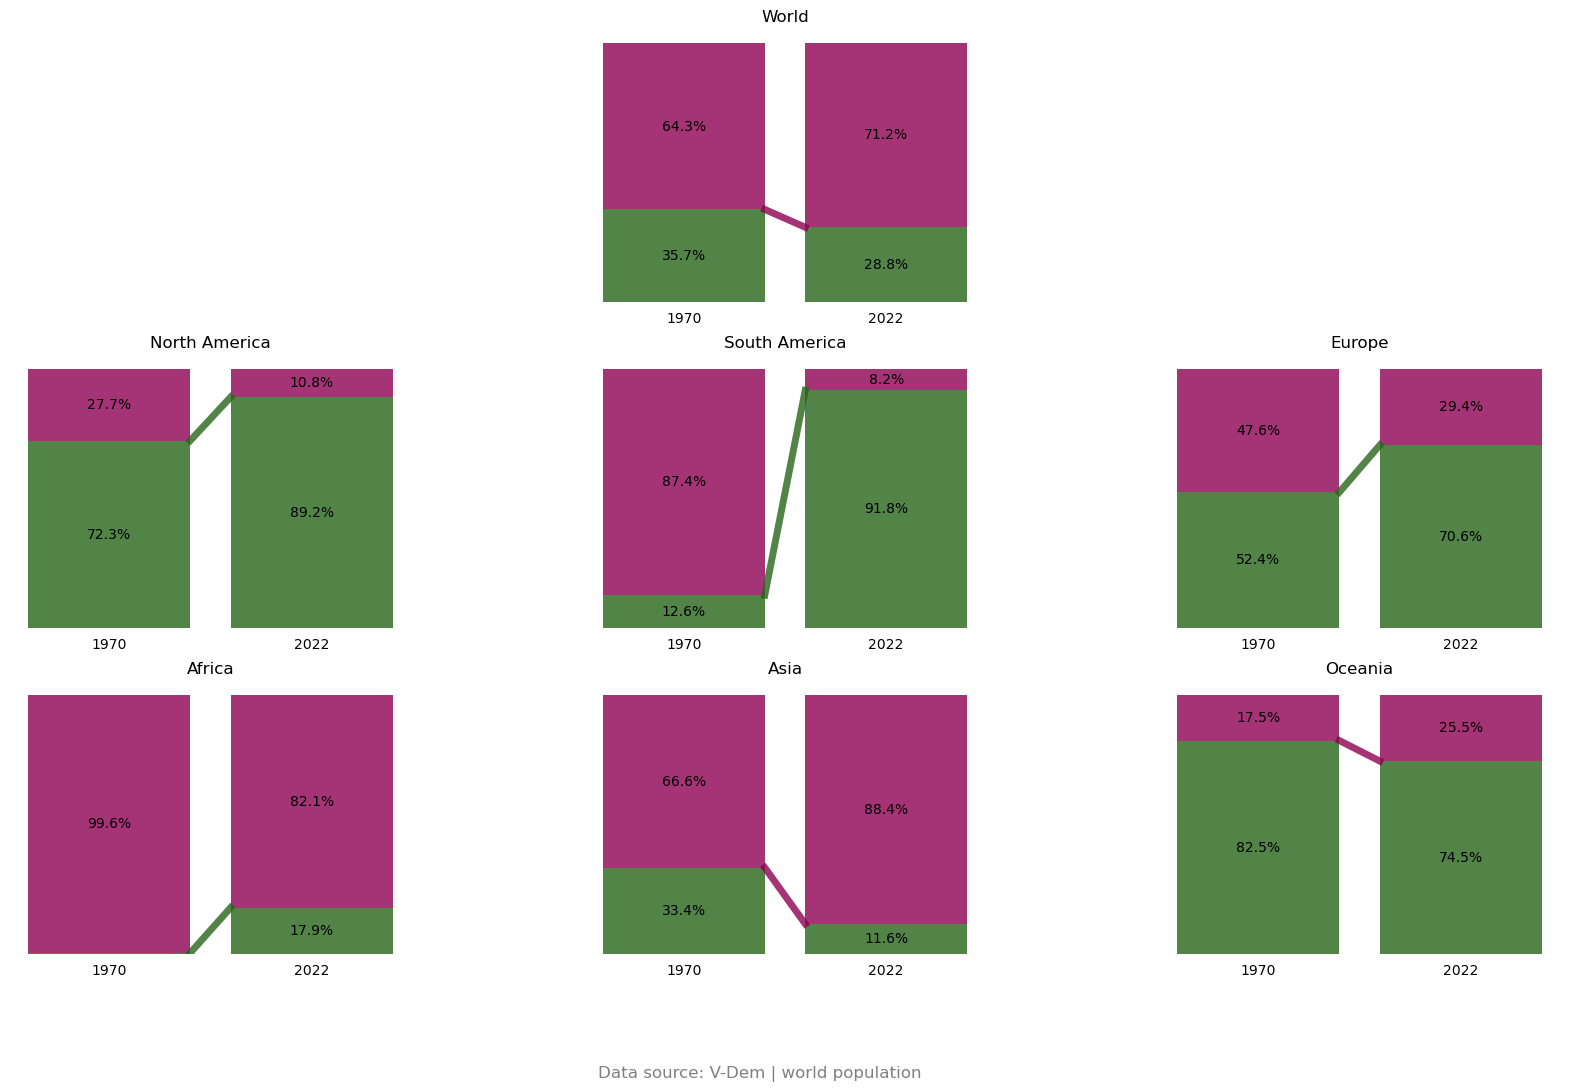

In [201]:
fig, axs = plt.subplots(figsize=(20,12), nrows=(3), ncols= 5,width_ratios = [6,1,6,1,6,])


# World
sizes = normalize([[sum(living_in_autocracy_1970.values()),sum(living_in_democracy_1970.values())],
        [sum(living_in_autocracy_2022.values()),sum(living_in_democracy_2022.values())]])


bar = axs[0,2].bar(["1970","2022"],[sizes[0][1],sizes[1][1]],color = colors[1],**stacked_barplot_style)
axs[0,2].bar_label(bar,labels = format_label([sizes[0][1],sizes[1][1]]),label_type="center")

x_list=[]
y_list=[]

x_list.append(bar[0].get_bbox().get_points()[1][0])
y_list.append(bar[0].get_bbox().get_points()[1][1])

x_list.append(bar[1].get_bbox().get_points()[0][0])
y_list.append(bar[1].get_bbox().get_points()[1][1])

axs[0,2].plot(x_list,y_list,c=colors[0],linewidth = 5,**stacked_barplot_style)


bar = axs[0,2].bar(["1970","2022"],[sizes[0][0],sizes[1][0]],bottom=[sizes[0][1],sizes[1][1]],color = colors[0],**stacked_barplot_style)
axs[0,2].bar_label(bar,labels = format_label([sizes[0][0],sizes[1][0]]),label_type="center")

axs[0,2].set_title("World")


remove_all_spines(axs[0,2])
axs[0,2].tick_params(left=False,labelleft=False,bottom = False,labelbottom = True)




iter_continents = iter(continents)

for index_y in range(1,3):
    for index_x in range(0,5,2):
        continent = next(iter_continents)
        sizes = normalize([[living_in_autocracy_1970[continent],living_in_democracy_1970[continent]],
                [living_in_autocracy_2022[continent],living_in_democracy_2022[continent]]])
        
        
        bar = axs[index_y,index_x].bar(["1970","2022"],[sizes[0][1],sizes[1][1]],color = colors[1],**stacked_barplot_style)    

        x_list=[]
        y_list=[]

        x_list.append(bar[0].get_bbox().get_points()[1][0])
        y_list.append(bar[0].get_bbox().get_points()[1][1])

        x_list.append(bar[1].get_bbox().get_points()[0][0])
        y_list.append(bar[1].get_bbox().get_points()[1][1])

        if y_list[0] > y_list[1]:
                axs[index_y,index_x].plot(x_list,y_list,color = colors[0],linewidth = 5,**stacked_barplot_style)
        else:
                axs[index_y,index_x].plot(x_list,y_list,color = colors[1],linewidth = 5,**stacked_barplot_style)



        bar = axs[index_y,index_x].bar(["1970","2022"],[sizes[0][0],sizes[1][0]],color = colors[0],bottom=[sizes[0][1],sizes[1][1]],**stacked_barplot_style)
        


        threshold = 0.025
        for c in axs[index_y,index_x].containers:
        # Filter the labels
                labels = [v if v > threshold else "" for v in c.datavalues]    
                axs[index_y,index_x].bar_label(c, labels=format_label(labels), label_type="center")


        axs[index_y,index_x].set_title(continent)

        remove_all_spines(axs[index_y,index_x])
        axs[index_y,index_x].tick_params(left=False,labelleft=False,bottom = False,labelbottom = True)





iter_continents = iter(continents)



axs[0,0].axis("off")
axs[0,1].axis("off")
axs[0,4].axis("off")



axs[0,1].axis("off")
axs[0,3].axis("off")
axs[1,1].axis("off")
axs[1,3].axis("off")
axs[2,1].axis("off")
axs[2,3].axis("off")

fig.text(0.5, 0.01, 'Data source: V-Dem | world population', ha='center', va='center', fontsize=12, color='gray')


plt.savefig("../../grafiken/people_autocracy_vs_democracy.png",bbox_inches = "tight",dpi = 200)

In [146]:
x_list=[]
y_list=[]
x_list.append(bar[0].get_bbox().get_points()[1][0])
y_list.append(bar[0].get_bbox().get_points()[1][1])

## 4th Plot Change

In [147]:
df_weighted.loc[df_weighted["country_name"] == "United States of America",["country_name"]] = "USA"

In [148]:
df_most_populated = df_weighted[df_weighted["year"] == 2022]

In [149]:
most_populated = df_most_populated.sort_values(by=["population"],ascending=False)["country_name"].head(10).values

In [150]:
mean_index_2022 = {}
for country in most_populated:
    mean_index_2022[country] = df_weighted[(df_weighted["country_name"] == country) & (df_weighted["year"] == 2022)]["mean"].values[0]

In [151]:
mean_index_2000 = {}
for country in most_populated:
    if country != "Bangladesh":
        mean_index_2000[country] = df_weighted[(df_weighted["country_name"] == country) & (df_weighted["year"] == 2000)]["mean"].values[0]
    else:
           mean_index_2000[country] = df_weighted[(df_weighted["country_name"] == country) & (df_weighted["year"] == 2001)]["mean"].values[0]




In [152]:
factor_index = {}
for country in mean_index_2000.keys():
    factor_index[country] = (mean_index_2022[country] / mean_index_2000[country]) -1

In [153]:
color = ["darkred" if  x < 0 else 'yellowgreen' for x in factor_index.values()] 

In [154]:
def format_tick(x, pos=None):
    if x > 0:
        out = "+" + str(round(x * 100)) + "%"
    else:
        out = str(round(x * 100)) + "%"
    return out


### not used in data Story

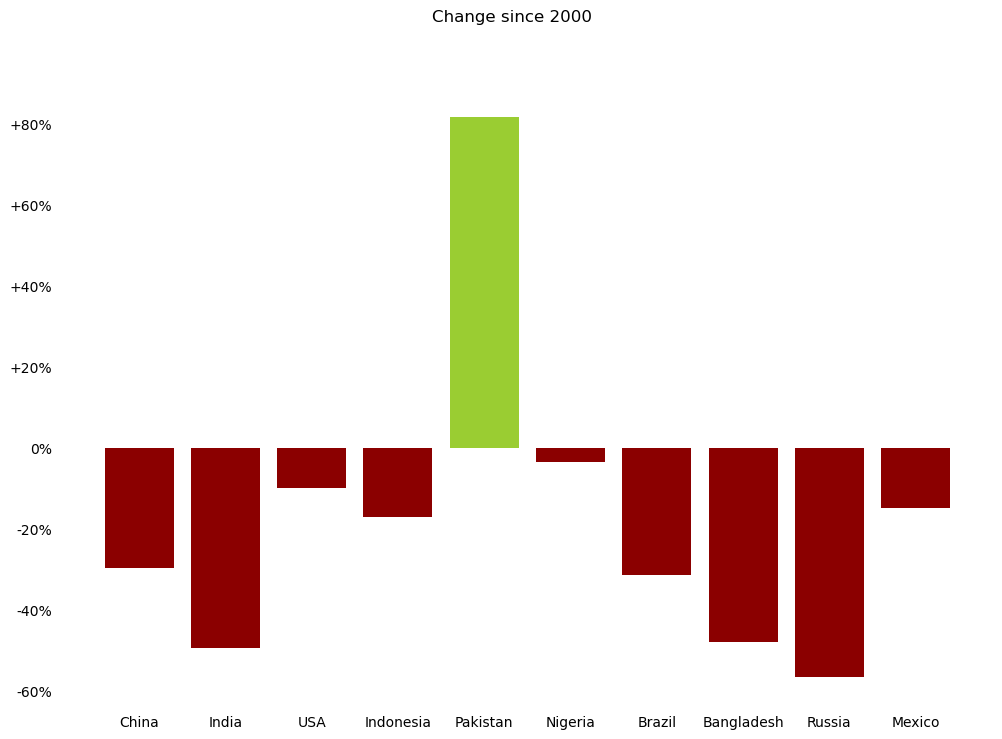

In [155]:
fig, ax = plt.subplots(figsize=(12,8))

ax.bar(factor_index.keys(),factor_index.values(),color = color)

ax.spines.top.set_visible(False)
ax.spines.bottom.set_visible(False)
ax.spines.left.set_visible(False)
ax.spines.right.set_visible(False)

ax.spines.left.set_visible(False)

ax.tick_params(bottom=False,left=False)


format = lambda x, pos: format_tick(x, pos)
ax.yaxis.set_major_formatter(format)

fig.suptitle("Change since 2000")

plt.savefig("../../grafiken/change_over_last_years.png",bbox_inches = "tight",dpi = 200)

In [156]:
mean_index_2000.keys()

dict_keys(['China', 'India', 'USA', 'Indonesia', 'Pakistan', 'Nigeria', 'Brazil', 'Bangladesh', 'Russia', 'Mexico'])

In [157]:
import flagpy as fp
flag_array = []
for element in mean_index_2000.keys():
    if element != "USA":
        flag_array.append(fp.get_flag_img(element))
    else:
        flag_array.append(fp.get_flag_img("The United States"))

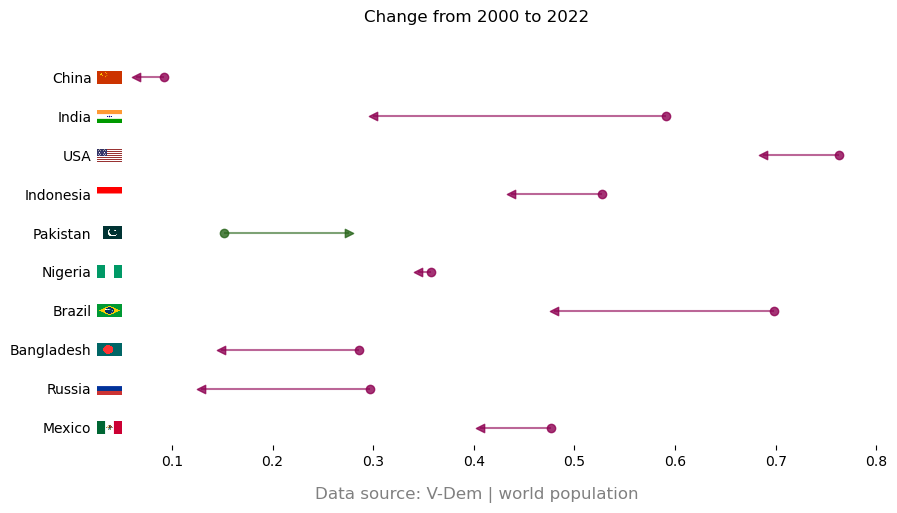

In [159]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

# Assuming mean_index_2000 and mean_index_2022 are already defined

df = pd.DataFrame({"country": reversed(mean_index_2022.keys()), '2000':reversed(mean_index_2000.values()), '2022': reversed(mean_index_2022.values())})

color = [cmap(0) if  x < 0 else cmap(400) for x in reversed(factor_index.values())] 

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10,5))

# The horizontal plot is made using the hline function
ax.hlines(y=df["country"], xmin=df['2000'], xmax=df['2022'], color=color, alpha=0.6)

for index,country in enumerate(reversed(mean_index_2000.keys())):
    ax.scatter(df.loc[df["country"] == country]["2000"], country, color=color[index], alpha=0.8,marker="o")

    if df.loc[df["country"] == country]["2000"].values > df.loc[df["country"] == country]["2022"].values:
        ax.scatter(df.loc[df["country"] == country]["2022"], country, color=cmap(0), alpha=0.8,marker="<") 
    else:
        ax.scatter(df.loc[df["country"] == country]["2022"],country,color=cmap(400), alpha=0.8,marker=">")

remove_all_spines(ax)
ax.tick_params(left=False)

ax.yaxis.set_ticks(df['country'])
ax.xaxis.set_ticks([x / 100.0 for x in range(10, 90, 10)])

for index in range(len(flag_array)):
    imagebox = OffsetImage(flag_array[index], zoom=0.1)
    ab = AnnotationBbox(imagebox, (0.038, 9-index), frameon = False,annotation_clip=False)
    ax.add_artist(ab)

fig.suptitle("Change from 2000 to 2022")
fig.text(0.5, 0.01, 'Data source: V-Dem | world population', ha='center', va='center', fontsize=12, color='gray')
plt.savefig("../../grafiken/change_over_last_years_improved.png",bbox_inches = "tight",dpi = 500)



## Table plot (not used in data story)

In [160]:
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import circled_image # image


In [161]:
df_happy = pd.read_csv("../../world_happiness_index/2019.csv")

In [162]:
df_temp_happy = df_progression.copy(deep=True)

In [163]:
list_mean = []
for _,row in df_happy.iterrows():
    try:
        list_mean.append(df_temp_happy.loc[(df_temp_happy["country_name"] == row["Country or region"]) & (df_temp_happy["year"] == 2019)]["mean"].values[0])
    except:
        list_mean.append(None)

In [164]:
df_happy = df_happy.assign(democracy=list_mean)

In [165]:
df_happy.dropna(inplace=True,axis=0,subset=["democracy"])

In [166]:
df_happy.drop("Overall rank",axis=1,inplace=True)

In [167]:
df_happy.sort_values(by="democracy",ascending=False,inplace=True)
df_happy.reset_index(inplace=True,drop=True)

In [168]:
df_happy.columns = ["country","score","GDP","social support","healty life","freedom","generosity","perception of corruption","democracy"]

In [169]:
df_happy_correlation = df_happy.copy(deep=True)

In [170]:
df_happy = pd.concat([df_happy.head(5),df_happy.tail(5)]) 
df_happy.drop("perception of corruption",axis=1,inplace=True)

In [171]:
df_happy = df_happy.round(2)


In [172]:
df_happy = df_happy.reindex(columns=["country","score","freedom","generosity","healty life","social support","democracy"])

In [173]:
# The 5 categories grouped into 2 maain ones
happiness = ["score", "freedom", "generosity"]
health = ["healty life ", "social support"]

## Define column definitions for creating the table with specific properties.
col_defs = (
    [
        ColumnDefinition(
            name="country",
            textprops={"ha": "left", "weight": "bold"},
            width=1.5,
        ),

        ColumnDefinition(
            name="score",
            width=0.75,
            textprops={
                "ha": "center",
                "bbox": {"boxstyle": "circle", "pad": 0.35},
            },
            cmap=normed_cmap(df_happy["score"], cmap=plt.cm.PiYG, num_stds=4),
            group="happiness",
        ),
        ColumnDefinition(
            name="freedom",
            width=0.75,
            textprops={
                "ha": "center",
                "bbox": {"boxstyle": "circle", "pad": 0.35},
            },
            cmap=normed_cmap(df_happy["freedom"], cmap=plt.cm.PiYG, num_stds=4),
            group="happiness",
        ),
         ColumnDefinition(
            name="generosity",
            width=0.75,
            textprops={
                "ha": "center",
                "bbox": {"boxstyle": "circle", "pad": 0.35},
            },
            cmap=normed_cmap(df_happy["generosity"], cmap=plt.cm.PiYG, num_stds=4),
            group="happiness",
        ),
          ColumnDefinition(
            name="healty life",
            width=0.75,
            textprops={
                "ha": "center",
                "bbox": {"boxstyle": "circle", "pad": 0.35},
            },
            cmap=normed_cmap(df_happy["healty life"], cmap=plt.cm.PiYG, num_stds=4),
            group="health",
        ),
             ColumnDefinition(
            name="social support",
            width=0.75,
            textprops={
                "ha": "center",
                "bbox": {"boxstyle": "circle", "pad": 0.35},
            },
            cmap=normed_cmap(df_happy["social support"], cmap=plt.cm.PiYG, num_stds=4),
            group="health",
        ),
         ColumnDefinition(
            name="democracy",
            width=0.75,
            textprops={
                "ha": "center",
                "bbox": {"boxstyle": "circle", "pad": 0.35},
            },
            cmap=normed_cmap(df_happy["democracy"], cmap=plt.cm.PiYG, num_stds=4),
        ),
    ])

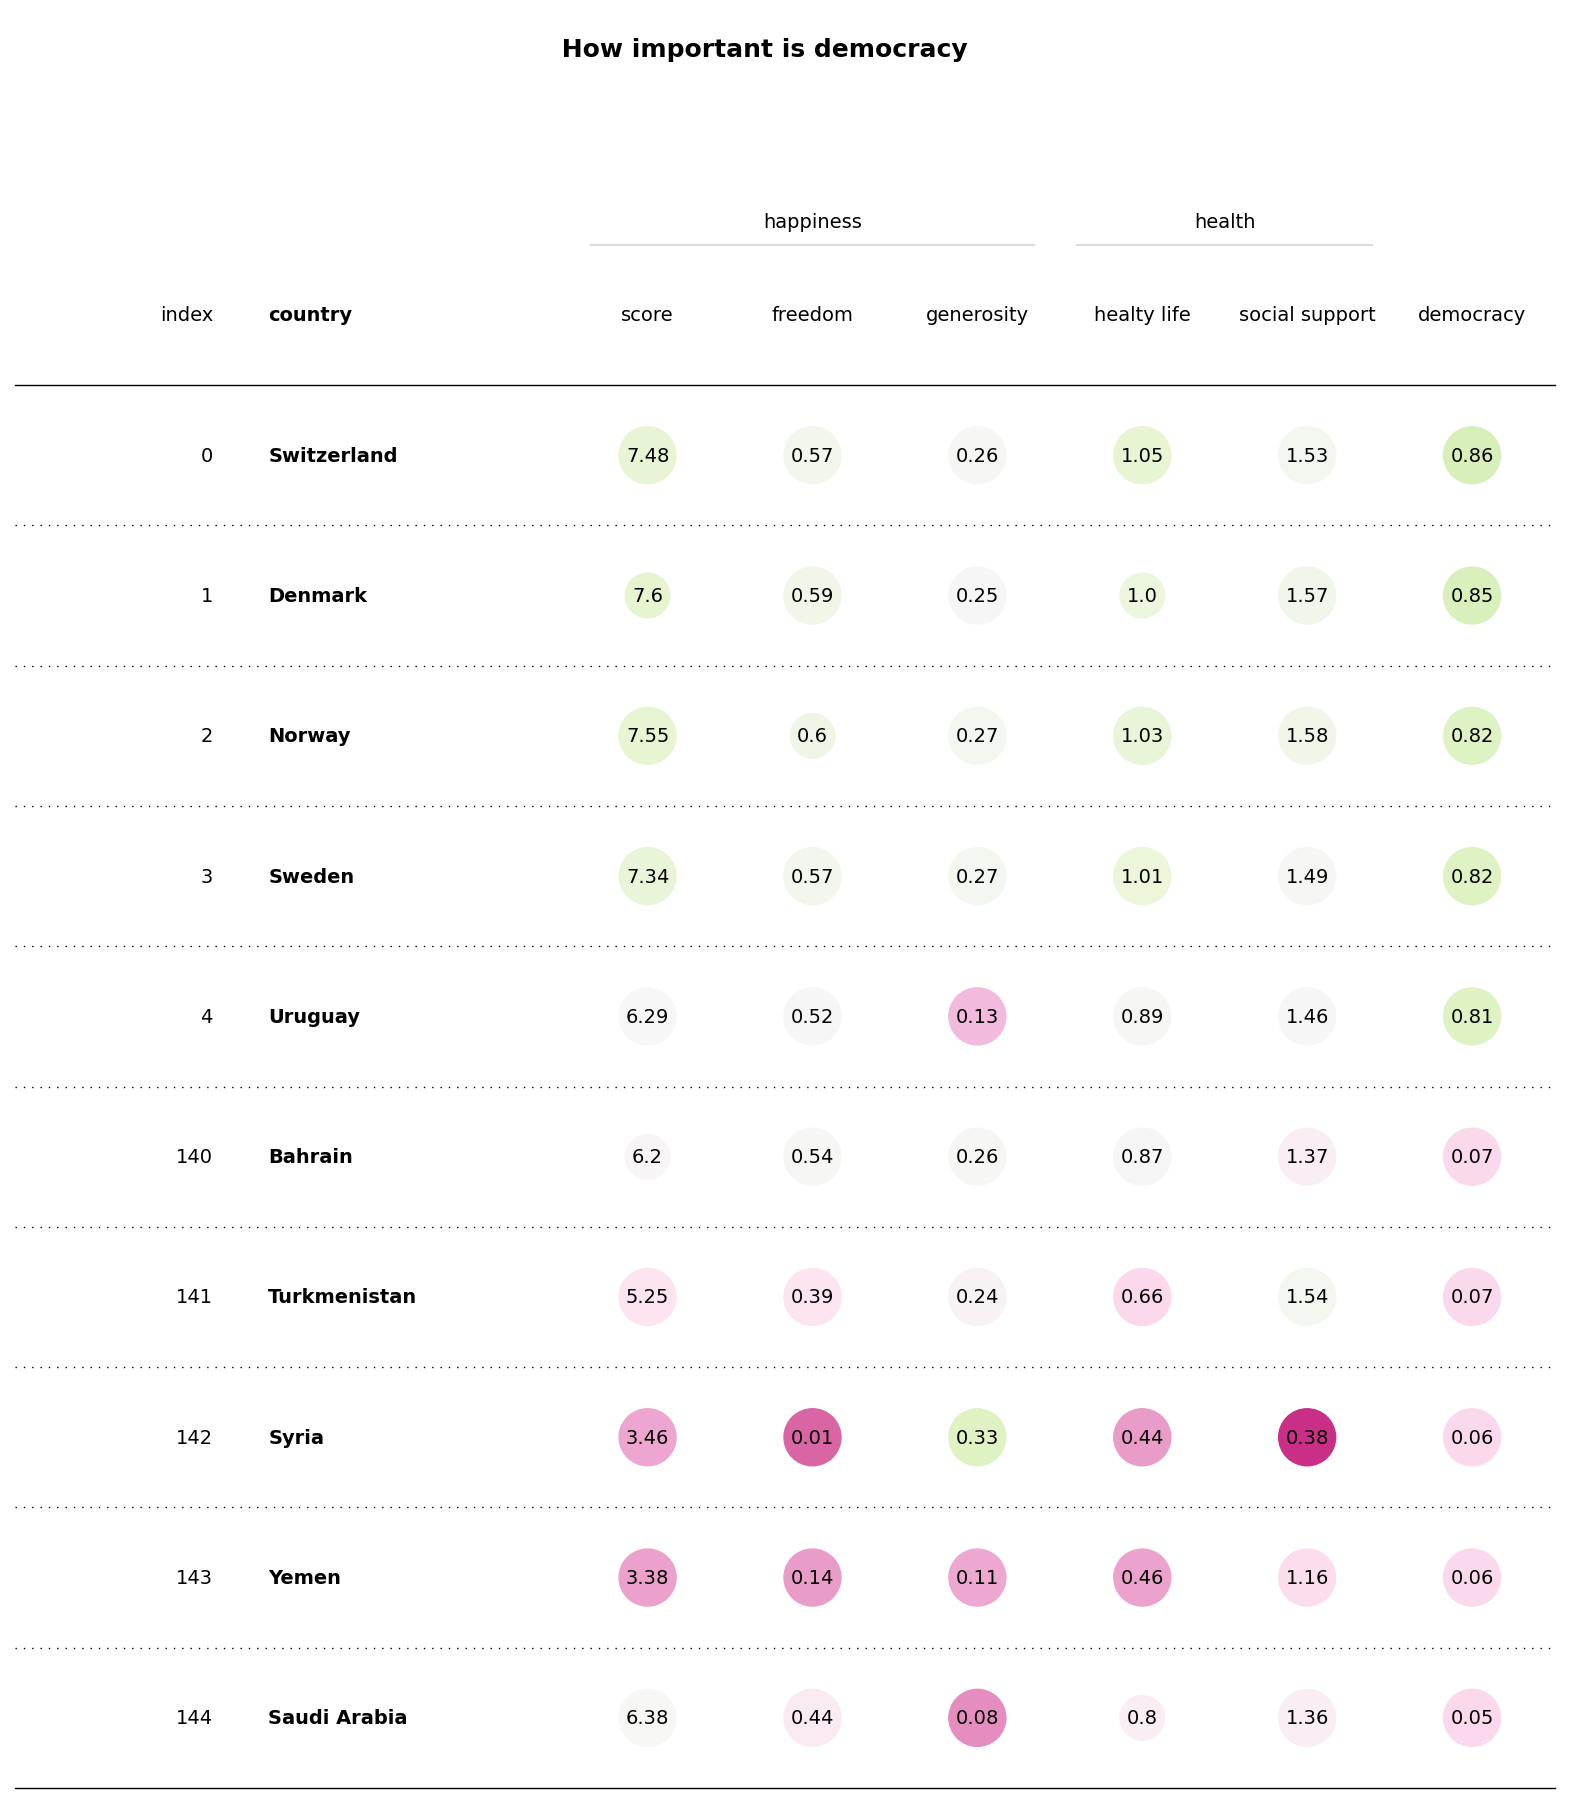

In [174]:
fig, ax = plt.subplots(figsize=(20, 22))

table = Table(
    df_happy,
    column_definitions=col_defs,
    row_dividers=True,
    footer_divider=True,
    ax=ax,
    textprops={"fontsize": 14},
    row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
    col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
    column_border_kw={"linewidth": 1, "linestyle": "-"},
)

# Adding the bold header as a text annotation using \n to create a new line
header_text = "\n How important is democracy"
header_props = {'fontsize': 18, 'fontweight': 'bold', 'va': 'center', 'ha': 'center'}
# Adjusting the y-coordinate to bring the header closer to the table
ax.text(0.5, 0.91, header_text, transform=fig.transFigure, **header_props)



# Adding the footer text
footer_text = "Source: The Economist Intelligence Unit • Visual and Analysis: Fortune Uwha"
footer_props = {'fontsize': 14, 'va': 'center', 'ha': 'center'}


fig.savefig("../../grafiken/positive_factors_of_democracy.png", facecolor=ax.get_facecolor(), dpi=200,bbox_inches = "tight")

# Correlation Plot

In [175]:
df_happy_correlation

,country,score,GDP,social support,healty life,freedom,generosity,perception of corruption,democracy
0,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343,0.8604
1,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,0.8514
2,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,0.8188
3,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373,0.8176
4,Uruguay,6.293,1.124,1.465,0.891,0.523,0.127,0.150,0.8112
...,...,...,...,...,...,...,...,...,...
140,Bahrain,6.199,1.362,1.368,0.871,0.536,0.255,0.110,0.0706
141,Turkmenistan,5.247,1.052,1.538,0.657,0.394,0.244,0.028,0.0686
142,Syria,3.462,0.619,0.378,0.440,0.013,0.331,0.141,0.0598
143,Yemen,3.380,0.287,1.163,0.463,0.143,0.108,0.077,0.0570


In [176]:
style = {
    "cmap" : "PiYG" , "c" : "democracy"
}

### not used in data story

Text(0.5, 0.98, 'How good is it to live in a democracy?')

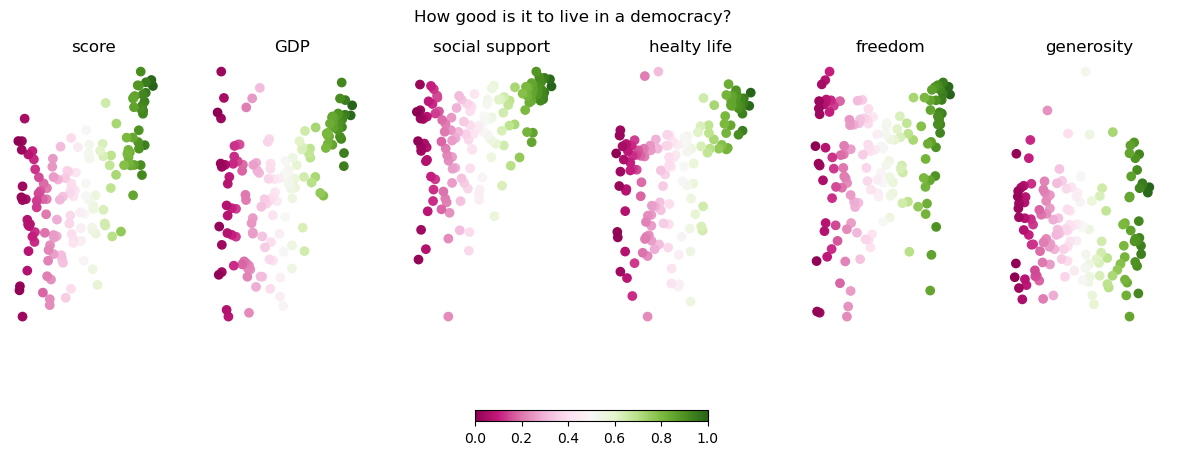

In [178]:
fig,ax = plt.subplots(figsize= (15,5),ncols=6,nrows=1,)

for index,coloumn in enumerate(df_happy_correlation.columns[1:-2]):
    m, b = np.polyfit(df_happy_correlation[coloumn], df_happy_correlation["democracy"], 1)
    ax[index].scatter("democracy", coloumn ,data = df_happy_correlation,**style)
    #ax[index].plot(df_happy_correlation[coloumn], m*df_happy_correlation[coloumn]+b, color='red')
    ax[index].set_title(coloumn)
    ax[index].set_xticks([0,0.2,0.4,0.6,0.8,1.0])
    
    remove_all_spines(ax[index])
    ax[index].tick_params(left=False,labelleft=False,bottom = False,labelbottom = False)

colorbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), orientation='horizontal',ax=ax,shrink=0.2,anchor=(0.5, 0.5) )
fig.suptitle("How good is it to live in a democracy?",)
    

### final version



In [179]:
df_happy_scaled = df_happy_correlation.copy()

In [180]:
for column in df_happy_scaled.loc[:,"score":].columns: 
    df_happy_scaled[column] = df_happy_scaled[column]  / df_happy_scaled[column].abs().max() 

In [181]:
df_happy_scaled.loc[:,"score":]
df_happy_scaled["index"] = [i for i in range(1, 11)] * 14 + [i for i in range(1,6)]

In [182]:
text_style = {"fontsize" : 9, "verticalalignment" : "center"}
arrow_style = {"head_starts_at_zero" : True, "shape" : "full", "head_length"  : 0.5,"head_width" : 0.01}

p:\anaconda\Lib\site-packages\matplotlib\text.py:757: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
p:\anaconda\Lib\site-packages\matplotlib\text.py:758: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
p:\anaconda\Lib\site-packages\matplotlib\text.py:897: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
p:\anaconda\Lib\site-packages\matplotlib\text.py:898: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


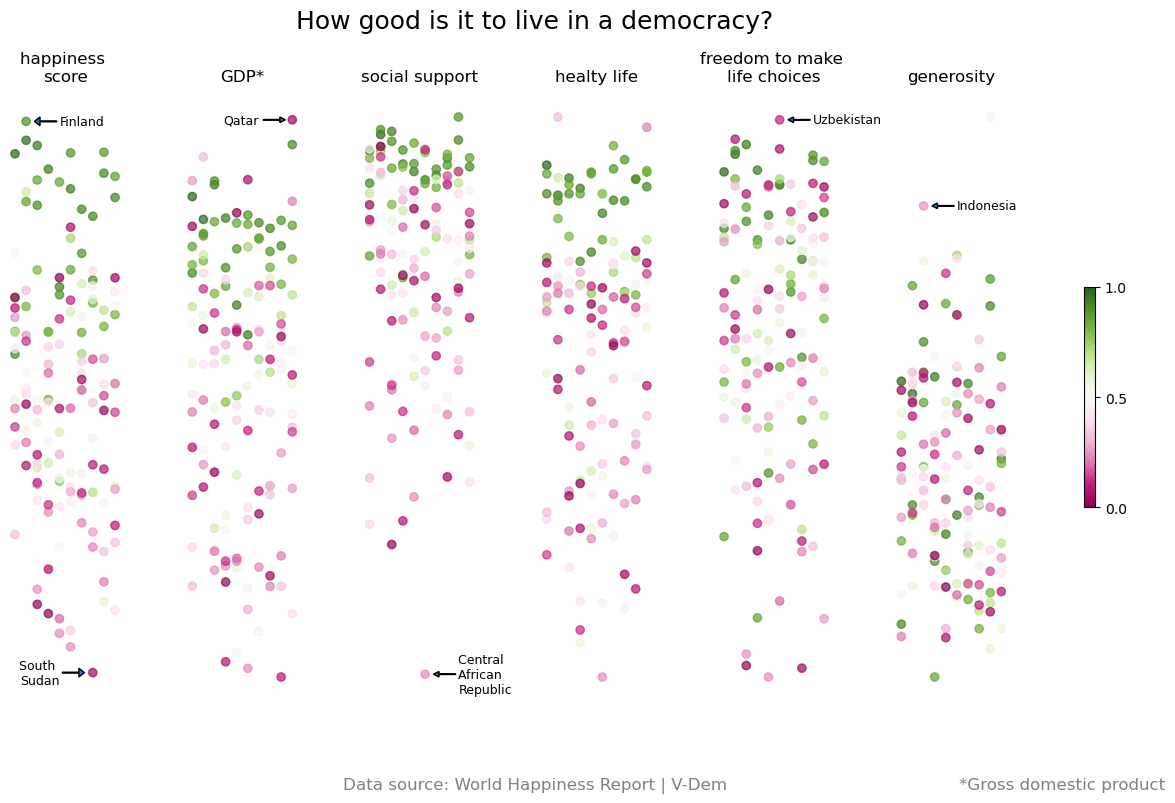

In [183]:
fig,ax = plt.subplots(figsize= (14,8),ncols=12,nrows=1,width_ratios=(3,1,3,1,3,1,3,1,3,1,3,2))
title = ["happiness \nscore","GDP*","social support","healty life","freedom to make \nlife choices","generosity"]

iter_index = iter(range(0,11,2))
for title_index,coloumn in enumerate(df_happy_correlation.columns[1:-2]):
    index = next(iter_index)

    ax[index].scatter(df_happy_scaled["index"],df_happy_scaled[coloumn],c=df_happy_scaled["democracy"],cmap = cmap,alpha = 0.7)
    ax[index].set_title(title[title_index],)
    
    remove_all_spines(ax[index])
    ax[index].tick_params(left=False,labelleft=False,bottom = False,labelbottom = False)

ax[1].remove()
ax[3].remove()
ax[5].remove()
ax[7].remove()
ax[9].remove()

remove_all_spines(ax[11])
ax[11].tick_params(left=False,labelleft=False,bottom = False,labelbottom = False)


colorbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), orientation='vertical',shrink=5, ax = ax[11],anchor=(0.5, 0.5) )
colorbar.ax.set_yticks([0,0.5,1])

fig.text(0.95, 0.01, '*Gross domestic product', ha='right', va='center', fontsize=12, color='gray')
fig.text(0.5, 0.01, 'Data source: World Happiness Report | V-Dem', ha='center', va='center', fontsize=12, color='gray')


#annotations
max_gdp = df_happy_scaled[df_happy_scaled["GDP"] == df_happy_scaled["GDP"].max()]
ax[2].text(max_gdp["index"].values[0] - 3,max_gdp.GDP.values[0],s = "Qatar", horizontalalignment = "right",**text_style)
ax[2].arrow(max_gdp["index"].values[0] - 2.87,max_gdp.GDP.values[0],1.5,0,**arrow_style)

max_generosity = df_happy_scaled.sort_values("generosity",axis=0,ascending=False).iloc[1]
ax[10].text(max_generosity["index"] + 3, max_generosity.generosity,s = "Indonesia",horizontalalignment = "left",**text_style)
ax[10].arrow(max_generosity["index"] + 3,max_generosity.generosity,-1.5,0,**arrow_style)


min_happiness = df_happy_scaled[df_happy_scaled["score"] == df_happy_scaled["score"].min()]
ax[0].text(min_happiness["index"].values[0] - 3, min_happiness.score.values[0],s = "South \nSudan",horizontalalignment = "right",**text_style)
ax[0].arrow(min_happiness["index"].values[0] - 3, min_happiness.score.values[0], 1.5, 0,**arrow_style)


max_happiness = df_happy_scaled[df_happy_scaled["score"] == df_happy_scaled["score"].max()]
ax[0].text(max_happiness["index"] + 3 , max_happiness.score,s = "Finland",horizontalalignment = "left", **text_style)
ax[0].arrow(max_happiness["index"].values[0] + 3, max_happiness.score.values[0], -1.5, 0,**arrow_style)

min_social_support = df_happy_scaled[df_happy_scaled["social support"] == df_happy_scaled["social support"].min()]
ax[4].text(min_social_support["index"].values[0] + 3 , min_social_support["social support"].values[0],s = "Central \nAfrican \nRepublic",horizontalalignment = "left", **text_style)
ax[4].arrow(min_social_support["index"].values[0] + 3, min_social_support["social support"].values[0], -1.5, 0,**arrow_style)

max_freedom = df_happy_scaled[df_happy_scaled["freedom"] == df_happy_scaled["freedom"].max()]
ax[8].text(max_freedom["index"].values[0] + 3 , max_freedom["freedom"].values[0],s = "Uzbekistan",horizontalalignment = "left",**text_style)
ax[8].arrow(max_freedom["index"].values[0] + 3, max_freedom["freedom"].values[0], -1.5, 0,**arrow_style)


fig.suptitle("How good is it to live in a democracy?",fontsize = 18)
fig.savefig("../../grafiken/positive_factors", dpi=200, bbox_inches = "tight")

### get requirements.txt

In [187]:
#!pipreqsnb . --force

pipreqs  --force .


INFO: Successfully saved requirements file in .\requirements.txt
